<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/Proekt_moda_ukr_/Map_02072026_notekooks/melbourne_houses_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Melbourne Housing Snapshot

  Dataset was scraped from publicly available results posted every week from Domain.com.au
  This is intended as a static (unchanging) snapshot of https://www.kaggle.com/anthonypino/melbourne-housing-market. It was created in September 2017. Additionally, homes with no Price have been removed.

#Overview
  File informations
- melb_data.csv(2.09 MB)
- number of Rows 13580
- namber of Columns 21


#

| Column name | Description | Example Value |
|---|---|---|
| Suburb | Suburb name | Abbotsford |
| Address | Street address | 85 Turner St |
| Rooms | Number of rooms | 2 |
| Type | h = house/cottage/villa/semi/terrace · u = unit/duplex · t = townhouse · dev site = development site · o res = other residential | h, u, t |
| Price | Price in dollars | 1480000 |
| Method | See note below | S, SP, PI |
| SellerG | Real Estate Agent | Biggin |
| Date | Date sold | 3/12/2016 |
| Distance | Distance from CBD | 2.5 |
| Postcode | Postcode | 3067 |
| Bedroom2 | Scraped # of Bedrooms (from different source) | 2 |
| Bathroom | Number of Bathrooms | 1 |
| Car | Number of carspots | 1 |
| Landsize | Land Size in m² | 202 |
| BuildingArea | Building Size in m² | 126 |
| YearBuilt | Year built | 1970 |
| CouncilArea | Governing council for the area | Yarra City Council |
| Lattitude | Latitude coordinate | -37.7996 |
| Longtitude | Longitude coordinate | 144.9984 |
| Regionname | General Region (West, North West, North, North East etc.) | Northern Metropolitan |
| Propertycount | Number of properties that exist in the suburb | 4019 |

---

**Method values:**
- **S** — property sold
- **SP** — sold prior
- **PI** — passed in
- **PN** — sold prior not disclosed
- **SN** — sold not disclosed
- **NB** — no bid
- **VB** — vendor bid
- **W** — withdrawn prior to auction
- **SA** — sold after auction
- **SS** — sold after auction, price not disclosed
- **N/A** — price or highest bid not available

!pip install numpy pandas matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
RANDOM_STATE = 42
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

FILE_IN = 'https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv'
FILE_OUT = "data/Melbourne_houses_analyse.csv"

df_origin = pd.read_csv(FILE_IN)



#Primary diagnosis

In [2]:
df_origin.head()
df = df_origin.copy()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


Problem:

Date columns (Transaction Date) as object

#Date column to date
python# Date column was loaded as a plain string (object type)


In [3]:
# We convert it to a proper datetime so we can extract year, month later
# dayfirst=True is critical — Australian date format is DD/MM/YYYY, not MM/DD/YYYY

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Dtype: {df['Date'].dtype}")

Date range: 2016-01-28 → 2017-09-23
Dtype: datetime64[ns]


Find  dirty  and Null values

In [4]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing/len(df) * 100).round(2)
missing_rep = pd.DataFrame({
    "count": missing,
    "%": missing_pct
})
#print(missing_rep)
missnotnull = missing_rep[missing_rep["%"] > 0]
print(missnotnull)

Missing values:

              count      %
Car              62   0.46
BuildingArea   6450  47.50
YearBuilt      5375  39.58
CouncilArea    1369  10.08


In [5]:
dirty = ["ERROR", "UNKNOWN", "UNK", "N/A", "?", "-", ""," " "NONE", "NULL"]

for col in ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount']:
    count = df[col].astype(str).str.upper().isin(dirty).sum()
    nan = df[col].isna().sum()
    display(f"{col}: брудних={count}, NaN={nan}")
print("-" *29)
print("Dirty values did not find")

'Suburb: брудних=0, NaN=0'

'Address: брудних=0, NaN=0'

'Rooms: брудних=0, NaN=0'

'Type: брудних=0, NaN=0'

'Price: брудних=0, NaN=0'

...

'Lattitude: брудних=0, NaN=0'

'Longtitude: брудних=0, NaN=0'

'Regionname: брудних=0, NaN=0'

'Propertycount: брудних=0, NaN=0'

-----------------------------
Dirty values did not find


# Chek unkorrekr values

In [6]:
checks = [
    ("Price <= 0",           (df["Price"] <= 0).sum()),
    ("Rooms <= 0",           (df["Rooms"] <= 0).sum()),
    ("Bedroom2 < 0",         (df["Bedroom2"] < 0).sum()),
    ("Bathroom < 0",         (df["Bathroom"] < 0).sum()),
    ("Car < 0",              (df["Car"] < 0).sum()),
    ("Landsize < 0",         (df["Landsize"] < 0).sum()),
    ("BuildingArea <= 0",    (df["BuildingArea"].notna() & (df["BuildingArea"] <= 0)).sum()),
    ("Distance < 0",         (df["Distance"] < 0).sum()),
    ("YearBuilt нереальний", (df["YearBuilt"].notna() & ((df["YearBuilt"] < 1800) | (df["YearBuilt"] > 2025))).sum()),
    ("Bedroom2 > Rooms",     (df["Bedroom2"].notna() & (df["Bedroom2"] > df["Rooms"])).sum()),
]

for label, count in checks:
    status = "OK" if count == 0 else f"! {count} записів"
    print(f"  {label:<30}: {status}")



  Price <= 0                    : OK
  Rooms <= 0                    : OK
  Bedroom2 < 0                  : OK
  Bathroom < 0                  : OK
  Car < 0                       : OK
  Landsize < 0                  : OK
  BuildingArea <= 0             : ! 17 записів
  Distance < 0                  : OK
  YearBuilt нереальний          : ! 1 записів
  Bedroom2 > Rooms              : ! 203 записів


# Заповнення пропущених значень

In [7]:
 #Прапорці наявності пропусків — до заповнення
df["flag_Car"]          = df["Car"].isna().astype(int)
df["flag_BuildingArea"] = df["BuildingArea"].isna().astype(int)
df["flag_YearBuilt"]    = df["YearBuilt"].isna().astype(int)
df["flag_CouncilArea"]  = df["CouncilArea"].isna().astype(int)

print("Прапорці створено:")
print(df[["flag_Car", "flag_BuildingArea", "flag_YearBuilt", "flag_CouncilArea"]].sum())

Прапорці створено:
flag_Car               62
flag_BuildingArea    6450
flag_YearBuilt       5375
flag_CouncilArea     1369
dtype: int64


In [8]:
print(f"Пропуски до заповнення:")
print(df[["Car", "BuildingArea", "YearBuilt", "CouncilArea"]].isna().sum())

Пропуски до заповнення:
Car               62
BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
dtype: int64


In [9]:
# Не логічні значення "YearBuilt"
df.loc[df["YearBuilt"].notna() & ((df["YearBuilt"] < 1800) | (df["YearBuilt"] > 2026)), "YearBuilt"] = np.nan
# BuildingArea <= 0 на NaN
mask_bad_area = df["BuildingArea"].notna() & (df["BuildingArea"] <= 0)
df.loc[mask_bad_area, "BuildingArea"] = np.nan
print(f"\nBuildingArea <= 0 замінено на NaN: {mask_bad_area.sum()} записів")

# Car NaN на 0
df["Car"] = df["Car"].fillna(0)
print(f"Car: пропуски заповнено нулями, залишилось NaN: {df['Car'].isna().sum()}")

# ЗАПОВНЕННЯ YearBuilt — каскадна медіана



#df["YearBuilt"] = df.groupby(["Suburb", "Type"])["YearBuilt"].transform(
    #lambda x: x.fillna(x.median()))
#df["YearBuilt"] = df.groupby(["Regionname", "Type"])["YearBuilt"].transform(
    #lambda x: x.fillna(x.median()))
#df["YearBuilt"] = df["YearBuilt"].fillna(df["YearBuilt"].median())
#print(f"YearBuilt після заповнення: {df['YearBuilt'].isna().sum()} пропусків")


# ЗАПОВНЕННЯ BuildingArea — медіана по групах

print(f"\nBuildingArea до заповнення: {df['BuildingArea'].isna().sum()} пропусків")

#df["BuildingArea"] = df.groupby(["Suburb", "Type", "Rooms", "Bedroom2"])["BuildingArea"].transform(
    #lambda x: x.fillna(x.median()))

#df["BuildingArea"] = df.groupby(["Suburb", "Type", "Rooms"])["BuildingArea"].transform(
    #lambda x: x.fillna(x.median()))

#df["BuildingArea"] = df.groupby(["Type", "Rooms", "Bedroom2"])["BuildingArea"].transform(
    #lambda x: x.fillna(x.median()))

#df["BuildingArea"] = df.groupby(["Type", "Rooms"])["BuildingArea"].transform(
    #lambda x: x.fillna(x.median()))

#df["BuildingArea"] = df["BuildingArea"].fillna(df["BuildingArea"].median())

print(f"BuildingArea після заповнення: {df['BuildingArea'].isna().sum()} пропусків")




BuildingArea <= 0 замінено на NaN: 17 записів
Car: пропуски заповнено нулями, залишилось NaN: 0

BuildingArea до заповнення: 6467 пропусків
BuildingArea після заповнення: 6467 пропусків


# Cheak

In [10]:
print(f"\nПропуски після очищення:")
print(df[["Car", "BuildingArea", "YearBuilt", "CouncilArea"]].isna().sum())
print(f"Розмір df: {df.shape}")


Пропуски після очищення:
Car                0
BuildingArea    6467
YearBuilt       5376
CouncilArea     1369
dtype: int64
Розмір df: (13580, 25)


#Крок 4. Дослідження (EDA)

розподіл цілі Price (

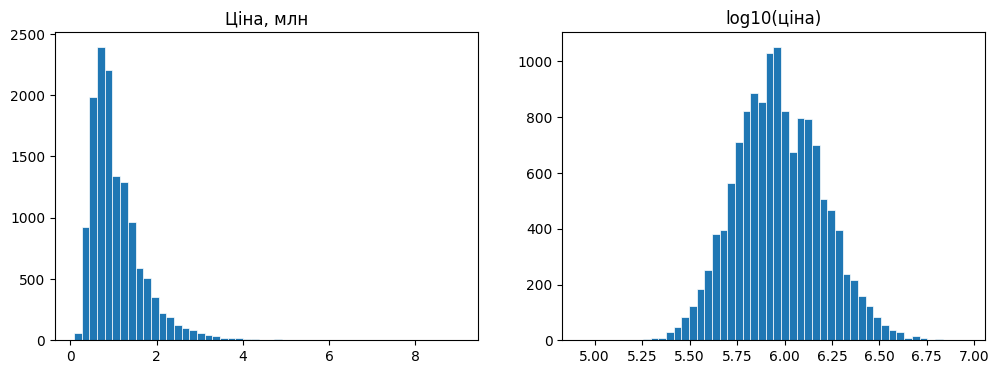

In [11]:

clean2 = df.copy()

if "Unnamed: 0" in clean2.columns:
    clean2 = clean2.drop(columns=["Unnamed: 0"])


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(clean2["Price"] / 1e6, bins=50, edgecolor='white', linewidth=0.5)
ax[0].set_title("Ціна, млн")

ax[1].hist(np.log10(clean2["Price"]), bins=50, edgecolor='white', linewidth=0.5)
ax[1].set_title("log10(ціна)")

plt.show()

як ціна залежить від типу житла та району;

In [12]:
df_ztype = df.groupby(['Type'])['Price'].mean().sort_values(ascending=False)/1000
df_ztype.round(1)

,Price
Type,
h,1242.7
t,933.7
u,605.1


зв'язок числових ознак із ціною (кореляції)

In [13]:
corr2 = df.select_dtypes(include='number').corr()['Price'].drop('Price').abs().sort_values()
print(corr2.round(2))

flag_BuildingArea    0.01
flag_YearBuilt       0.02
flag_Car             0.02
Landsize             0.04
Propertycount        0.04
flag_CouncilArea     0.06
BuildingArea         0.09
Postcode             0.11
Distance             0.16
Longtitude           0.20
Lattitude            0.21
Car                  0.23
YearBuilt            0.33
Bathroom             0.47
Bedroom2             0.48
Rooms                0.50
Name: Price, dtype: float64


чи немає пар ознак, які майже дублюють одна одну

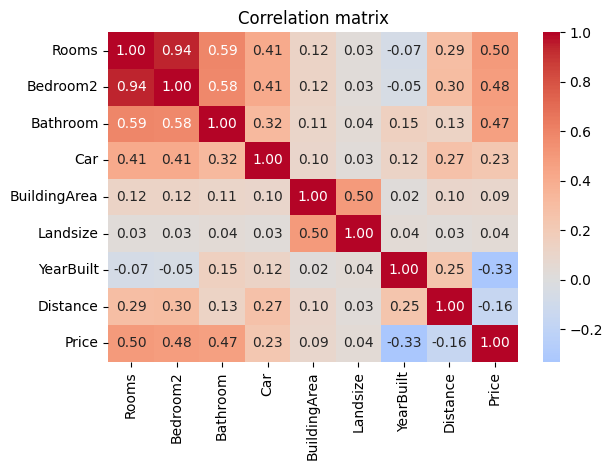

In [14]:
import seaborn as sns

cols = ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'BuildingArea', 'Landsize', 'YearBuilt', 'Distance', 'Price']

sns.heatmap(df[cols].corr().round(2), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

 #Крок 5. Нові ознаки (feature engineering) вік будинку, залежність району від віддаленості від центру


In [15]:
df['Sale_month']    = df['Date'].dt.month
#df['Build_density'] = df['BuildingArea'] / (df['Landsize'] + 1)
df["YearSale"] = pd.to_datetime(df["Date"], dayfirst=True).dt.year



invalid = (df["YearBuilt"] > df["YearSale"]).sum()
df.loc[df["YearBuilt"] > df["YearSale"], "YearBuilt"] = np.nan
print(f"\nНекоректних YearBuilt → NaN: {invalid}")

print(df['Sale_month'].describe().round(2))


Некоректних YearBuilt → NaN: 6
count    13580.00
mean         7.05
std          2.54
min          1.00
25%          5.00
50%          7.00
75%          9.00
max         12.00
Name: Sale_month, dtype: float64


2

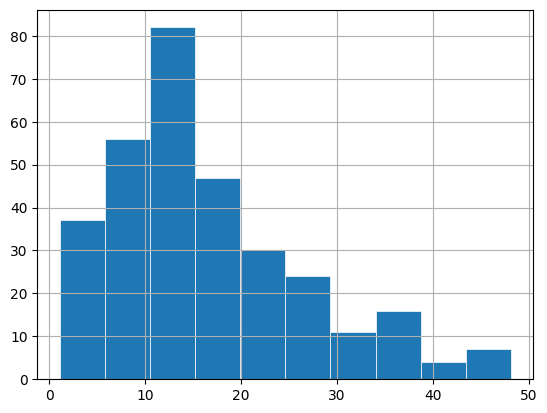

In [16]:
sub_dis = df.groupby('Suburb')['Distance'].mean().sort_values()
sub_dis.describe()
s = sub_dis.hist(bins=10, edgecolor='white', linewidth=0.5)
plt.show()

In [17]:
# Distance zone — ordinal feature based on distance from CBD
# 1 = closest, 10 = furthest
df['Distance_zone'] = pd.cut(df['Distance'], bins=10, labels=range(1, 11)).astype(int)

print(df['Distance_zone'].value_counts().sort_index())

Distance_zone
1     2212
2     4789
3     4533
4     1207
5      440
6      166
7      103
8      104
9        9
10      17
Name: count, dtype: int64


In [18]:
# МОДЕЛЬ: Прогнозування ціни (Price)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
# Відбір рядків де є ціна + One-Hot Encoding
df_price = pd.get_dummies(df.dropna(subset=["Price"]).copy(),
                          columns=["Type", "Regionname", ], drop_first=True) #"CouncilArea"

type_cols_p    = [c for c in df_price.columns if c.startswith("Type_")]
region_cols_p  = [c for c in df_price.columns if c.startswith("Regionname_")]


features_price = ["Rooms", "Bathroom", "Car", "Landsize",  "Sale_month",
                  "Distance", "Propertycount",  ] \
                + type_cols_p + region_cols_p

df_pm = df_price[features_price + ["Price"]].dropna()
print(f"Ознак: {len(features_price)}  |  Рядків: {len(df_pm)}\n")

X_train, X_test, y_train, y_test = train_test_split(
    df_pm[features_price], df_pm["Price"], test_size=0.2, random_state=42)

# Три моделі
pipe_lr_p = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe_rf_p = Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
pipe_gb_p = Pipeline([("scaler", StandardScaler()), ("model", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42))])

pipe_lr_p.fit(X_train, y_train)
y_pred_lr_p = pipe_lr_p.predict(X_test)
print("Лінійна регресія R2=", round(r2_score(y_test, y_pred_lr_p), 4), "MAE=", round(mean_absolute_error(y_test, y_pred_lr_p), 0), "$")

pipe_rf_p.fit(X_train, y_train)
y_pred_rf_p = pipe_rf_p.predict(X_test)
print("Random Forest R2=", round(r2_score(y_test, y_pred_rf_p), 4), "MAE=", round(mean_absolute_error(y_test, y_pred_rf_p), 0), "$")

pipe_gb_p.fit(X_train, y_train)
y_pred_gb_p = pipe_gb_p.predict(X_test)
print("Gradient Boosting R2=", round(r2_score(y_test, y_pred_gb_p), 4), "MAE=", round(mean_absolute_error(y_test, y_pred_gb_p), 0), "$")

# Топ-10 ознак кращої моделі (Gradient Boosting)
y_pred_gb_p = pipe_gb_p.predict(X_test)
importances_p = pd.Series(pipe_gb_p.named_steps["model"].feature_importances_,
                           index=features_price).sort_values(ascending=False)

print("Топ-10 ознак (Gradient Boosting):")
for feat, imp in importances_p.head(10).items():
    print(" ", feat, ":", round(imp, 4))



Ознак: 16  |  Рядків: 13580

Лінійна регресія R2= 0.5881 MAE= 278125.0 $
Random Forest R2= 0.7874 MAE= 185003.0 $
Gradient Boosting R2= 0.8029 MAE= 180799.0 $
Топ-10 ознак (Gradient Boosting):
  Regionname_Southern Metropolitan : 0.2251
  Distance : 0.1868
  Rooms : 0.1718
  Landsize : 0.1308
  Bathroom : 0.1046
  Type_u : 0.09
  Propertycount : 0.0414
  Regionname_Northern Metropolitan : 0.012
  Type_t : 0.01
  Regionname_Western Metropolitan : 0.0096


In [19]:
print(df_price[features_price].isna().sum())

Rooms                                    0
Bathroom                                 0
Car                                      0
Landsize                                 0
Sale_month                               0
Distance                                 0
Propertycount                            0
Type_t                                   0
Type_u                                   0
Regionname_Eastern Victoria              0
Regionname_Northern Metropolitan         0
Regionname_Northern Victoria             0
Regionname_South-Eastern Metropolitan    0
Regionname_Southern Metropolitan         0
Regionname_Western Metropolitan          0
Regionname_Western Victoria              0
dtype: int64


In [20]:
from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
y_base = baseline.predict(X_test)
print(f"Baseline MAE={mean_absolute_error(y_test, y_base):,.0f} $")
print(f"Baseline R2={r2_score(y_test, y_base):.4f}")

Baseline MAE=461,258 $
Baseline R2=-0.0000


In [21]:
# Один рядок з тестової вибірки
example = X_test.iloc[[0]]
real_price = y_test.iloc[0]
predicted = pipe_gb_p.predict(example)[0]
print(f"Реальна ціна: {real_price:,.0f} $")
print(f"Прогноз:      {predicted:,.0f} $")
print(f"Похибка:      {abs(real_price - predicted):,.0f} $")

Реальна ціна: 2,600,000 $
Прогноз:      2,114,120 $
Похибка:      485,880 $


In [22]:
# Один рядок з тестової вибірки
example = X_test.iloc[[0]]
real_price = y_test.iloc[0]
predicted = pipe_rf_p.predict(example)[0]
print(f"Реальна ціна: {real_price:,.0f} $")
print(f"Прогноз:      {predicted:,.0f} $")
print(f"Похибка:      {abs(real_price - predicted):,.0f} $")

Реальна ціна: 2,600,000 $
Прогноз:      2,268,048 $
Похибка:      331,952 $


In [23]:
# Один рядок з тестової вибірки
example = X_test.iloc[[0]]
real_price = y_test.iloc[0]
predicted = pipe_lr_p.predict(example)[0]
print(f"Реальна ціна: {real_price:,.0f} $")
print(f"Прогноз:      {predicted:,.0f} $")
print(f"Похибка:      {abs(real_price - predicted):,.0f} $")

Реальна ціна: 2,600,000 $
Прогноз:      1,619,843 $
Похибка:      980,157 $


In [24]:
df.shape

(13580, 28)

In [ ]:
df

https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv